In [2]:
import json
import numpy as np
import pdal
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import laspy
import plotly.express as px
from pyproj import Proj
import pandas as pd
import geopandas as gpd
from shapely.geometry import box


In [30]:
strip1 = "/Volumes/Till_SSD/Lidar_Peel_2025/laz_output/FULL_ALS_L1B_20250801T161942_162119.laz"
strip2 = "/Volumes/Till_SSD/Lidar_Peel_2025/laz_output/FULL_ALS_L1B_20250801T163718_164138.laz"

In [31]:
def get_bounds(laz):
    p = pdal.Pipeline(json.dumps({"pipeline": [laz]}))
    p.execute()

    md = p.metadata if isinstance(p.metadata, dict) else json.loads(p.metadata)
    r = md["metadata"]["readers.las"]

    return {
        "minx": r["minx"],
        "maxx": r["maxx"],
        "miny": r["miny"],
        "maxy": r["maxy"],
    }


b1 = get_bounds(strip1)
b2 = get_bounds(strip2)
b1, b2


({'minx': -2392280.21, 'maxx': -2386234.05, 'miny': -2730.91, 'maxy': 1656.35},
 {'minx': -2393888.75, 'maxx': -2378430.61, 'miny': -4324.69, 'maxy': 5595.75})

In [32]:
minx = max(b1["minx"], b2["minx"])
maxx = min(b1["maxx"], b2["maxx"])
miny = max(b1["miny"], b2["miny"])
maxy = min(b1["maxy"], b2["maxy"])

(minx, maxx, miny, maxy)


(-2392280.21, -2386234.05, -2730.91, 1656.35)

In [33]:
def load_overlap_xyz(laz, bounds):
    minx, maxx, miny, maxy = bounds
    crop_bounds = f"([{minx},{maxx}],[{miny},{maxy}])"

    pipeline = {
        "pipeline": [
            laz,
            {"type": "filters.crop", "bounds": crop_bounds}
        ]
    }

    p = pdal.Pipeline(json.dumps(pipeline))
    p.execute()

    arr = p.arrays[0]
    return np.vstack([arr["X"], arr["Y"], arr["Z"]]).T

In [34]:
bounds = (minx, maxx, miny, maxy)

xyz1 = load_overlap_xyz(strip1, bounds)
xyz2 = load_overlap_xyz(strip2, bounds)

xyz1.shape, xyz2.shape

((9768599, 3), (11705320, 3))

In [35]:
def subsample(xyz, n=300_000, seed=42):
    if xyz.shape[0] <= n:
        return xyz
    rng = np.random.default_rng(seed)
    idx = rng.choice(xyz.shape[0], n, replace=False)
    return xyz[idx]

xyz1s = subsample(xyz1)
xyz2s = subsample(xyz2)

xyz1s.shape, xyz2s.shape

((300000, 3), (300000, 3))

In [36]:
tree = cKDTree(xyz2s[:, :2])
dist, idx = tree.query(xyz1s[:, :2], k=1)


In [37]:
max_dist = 1.5  # metres – adjust if needed
mask = dist <= max_dist

np.sum(mask), mask.size

dz = xyz2s[idx[mask], 2] - xyz1s[mask, 2]
np.mean(dz), np.median(dz), np.std(dz)

(np.float64(-0.06026467774510151),
 np.float64(-0.06000000000000005),
 np.float64(1.931438390934596))

In [38]:
med = np.median(dz)
mad = np.median(np.abs(dz - med))
mad_sigma = 1.4826 * mad

lo, hi = np.quantile(dz, [0.05, 0.95])
trimmed = dz[(dz >= lo) & (dz <= hi)]

{
    "n": dz.size,
    "mean": float(np.mean(dz)),
    "median": float(med),
    "std": float(np.std(dz)),
    "MAD": float(mad),
    "MAD_sigma": float(mad_sigma),
    "trimmed_mean_5_95": float(np.mean(trimmed)),
}


{'n': 28223,
 'mean': -0.06026467774510151,
 'median': -0.06000000000000005,
 'std': 1.931438390934596,
 'MAD': 0.6000000000000001,
 'MAD_sigma': 0.8895600000000001,
 'trimmed_mean_5_95': -0.05801393591055823}

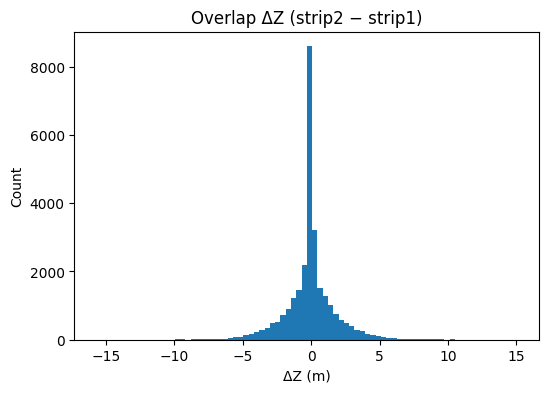

In [39]:
plt.figure(figsize=(6,4))
plt.hist(dz, bins=80)
plt.xlabel("ΔZ (m)")
plt.ylabel("Count")
plt.title("Overlap ΔZ (strip2 − strip1)")
plt.show()


In [25]:
las1 = laspy.read(strip1)
las2 = laspy.read(strip2)

step = 100  # adjust if needed

pts1 = np.vstack((las1.x, las1.y, las1.z)).T[::step]
pts2 = np.vstack((las2.x, las2.y, las2.z)).T[::step]

In [26]:
proj_3413 = Proj("epsg:3413", preserve_units=False)

lon1, lat1 = proj_3413(pts1[:, 0], pts1[:, 1], inverse=True)
lon2, lat2 = proj_3413(pts2[:, 0], pts2[:, 1], inverse=True)

df = pd.DataFrame({
    "lon": np.concatenate([lon1, lon2]),
    "lat": np.concatenate([lat1, lat2]),
    "elevation": np.concatenate([pts1[:, 2], pts2[:, 2]]),
    "strip": (["Strip 1"] * len(pts1)) + (["Strip 2"] * len(pts2))
})


In [27]:
fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="strip",
    zoom=5,
    opacity=0.7,
    labels={"strip": "ALS strip"}
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()


/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_14856/4147347625.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



ERROR 1: dlopen(/Users/tillweiss/miniconda3/envs/lidar_env/lib/gdalplugins/ogr_PG.dylib, 0x0001): Library not loaded: /usr/lib/libpq.5.dylib
  Referenced from: <DB805787-BEA2-3EB0-A5DB-EA3055280783> /Users/tillweiss/miniconda3/envs/lidar_env/lib/gdalplugins/ogr_PG.dylib
  Reason: tried: '/usr/lib/libpq.5.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/lib/libpq.5.dylib' (no such file), '/usr/lib/libpq.5.dylib' (no such file, not in dyld cache), '/usr/local/lib/libpq.5.dylib' (no such file)
ERROR 1: dlopen(/Users/tillweiss/miniconda3/envs/lidar_env/lib/gdalplugins/ogr_PG.dylib, 0x0001): Library not loaded: /usr/lib/libpq.5.dylib
  Referenced from: <DB805787-BEA2-3EB0-A5DB-EA3055280783> /Users/tillweiss/miniconda3/envs/lidar_env/lib/gdalplugins/ogr_PG.dylib
  Reason: tried: '/usr/lib/libpq.5.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/lib/libpq.5.dylib' (no such file), '/usr/lib/libpq.5.dylib' (no such file, not in dyld cache), '/usr/local/lib/libpq.

GeoPackage written: /Volumes/Till_SSD/Lidar_Peel_2025/dsampled/strip_overlap_core.gpkg
Shrunk overlap bounds:
-2390769.3125 -2387747.5175 -1632.8624999999997 558.6925


Text(0.5, 1.0, 'Shrunk overlap area (core)')

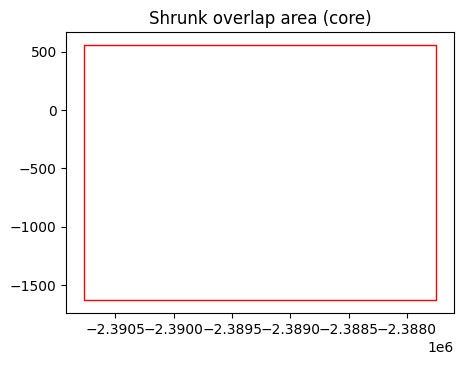

In [28]:
import geopandas as gpd
from shapely.geometry import box

# -------------------------------------------------------------------
# INPUT: overlap bounds (EPSG:3413)
# -------------------------------------------------------------------
# Replace these with your actual overlap bounds
minx, maxx, miny, maxy = bounds  # e.g. bounds = (minx, maxx, miny, maxy)

# How much of the overlap to keep (0.5 = 50%)
shrink_factor = 0.5

# Output
out_gpkg = "/Volumes/Till_SSD/Lidar_Peel_2025/dsampled/strip_overlap_core.gpkg"
layer_name = "overlap_core"

# -------------------------------------------------------------------
# FUNCTIONS
# -------------------------------------------------------------------
def shrink_bounds(minx, maxx, miny, maxy, factor=0.5):
    """
    Shrink bounding box by a given factor around its centre.
    factor = 0.5 -> half width & height
    """
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    half_width = (maxx - minx) * factor / 2
    half_height = (maxy - miny) * factor / 2

    return (
        cx - half_width,
        cx + half_width,
        cy - half_height,
        cy + half_height
    )

# -------------------------------------------------------------------
# CREATE SHRUNK OVERLAP POLYGON
# -------------------------------------------------------------------
minx_s, maxx_s, miny_s, maxy_s = shrink_bounds(
    minx, maxx, miny, maxy, factor=shrink_factor
)

geom = box(minx_s, miny_s, maxx_s, maxy_s)

gdf = gpd.GeoDataFrame(
    {"name": [layer_name]},
    geometry=[geom],
    crs="EPSG:3413"
)

# -------------------------------------------------------------------
# WRITE TO GEOPACKAGE
# -------------------------------------------------------------------
gdf.to_file(out_gpkg, layer=layer_name, driver="GPKG")

print(f"GeoPackage written: {out_gpkg}")
print("Shrunk overlap bounds:")
print(minx_s, maxx_s, miny_s, maxy_s)

# -------------------------------------------------------------------
# QUICK SANITY PLOT (optional, but useful in Jupyter)
# -------------------------------------------------------------------
ax = gdf.plot(edgecolor="red", facecolor="none", figsize=(5, 5))
ax.set_title("Shrunk overlap area (core)")


In [29]:
import os
import numpy as np
import laspy
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from shapely.geometry import box
from pyproj import Proj, Transformer



# overlap bounds in EPSG:3413 (from previous steps)
minx, maxx, miny, maxy = bounds

shrink_factor = 0.5   # 50% overlap core
step = 100            # subsampling for plotting



pts1 = np.vstack((las1.x, las1.y, las1.z)).T[::step]
pts2 = np.vstack((las2.x, las2.y, las2.z)).T[::step]

# -------------------------------------------------------------------
# PROJECTION: EPSG:3413 -> WGS84
# -------------------------------------------------------------------
transformer = Transformer.from_crs(3413, 4326, always_xy=True)

lon1, lat1 = transformer.transform(pts1[:, 0], pts1[:, 1])
lon2, lat2 = transformer.transform(pts2[:, 0], pts2[:, 1])

# -------------------------------------------------------------------
# COMBINE STRIPS INTO ONE DATAFRAME
# -------------------------------------------------------------------
df = pd.DataFrame({
    "lon": np.concatenate([lon1, lon2]),
    "lat": np.concatenate([lat1, lat2]),
    "elevation": np.concatenate([pts1[:, 2], pts2[:, 2]]),
    "strip": (["Strip 1"] * len(pts1)) + (["Strip 2"] * len(pts2))
})

# -------------------------------------------------------------------
# CREATE SHRUNK OVERLAP POLYGON (EPSG:3413)
# -------------------------------------------------------------------
cx = (minx + maxx) / 2
cy = (miny + maxy) / 2

half_w = (maxx - minx) * shrink_factor / 2
half_h = (maxy - miny) * shrink_factor / 2

poly_3413 = box(
    cx - half_w,
    cy - half_h,
    cx + half_w,
    cy + half_h
)

# Convert polygon to lat/lon
pxy = np.array(poly_3413.exterior.coords)
poly_lon, poly_lat = transformer.transform(pxy[:, 0], pxy[:, 1])

# -------------------------------------------------------------------
# PLOT
# -------------------------------------------------------------------
fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="strip",
    zoom=5,
    opacity=0.6,
    labels={"strip": "ALS strip"}
)

# Add overlap polygon outline
fig.add_trace(
    go.Scattermapbox(
        lon=poly_lon,
        lat=poly_lat,
        mode="lines",
        line=dict(width=3, color="red"),
        name="Overlap core"
    )
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r": 0, "t": 0, "l": 0, "b": 0}
)

fig.show()


/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_14856/884064347.py:64: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_14856/884064347.py:76: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

